In [17]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
path = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Simulation_Related/OLMT_Calibration/Plots/Ensemble_ts_plots"

In [185]:
fname = "FACE_r250125_CalibrationNonLogEx_RD_US-DUK_I20TRELMFATES_aCO2combined_output"
#fname = "FACE_r250124_CalibrationEx_RD_US-DUK_I20TRELMFATES_aCO2combined_output"
#fname = "FACE_r250125_CalibrationNonLogEx_RD_US-DUK_I20TRELMFATES_aCO2_combined_response_output"
#fname = "FACE_r250124_CalibrationEx_RD_US-DUK_I20TRELMFATES_aCO2_combined_response_output"
#fname = "FACE_r250204_CalibrationNonLogEx_RD_US-ORN_I20TRELMFATES_aCO2combined_output"
fname = "FACE_r250204_CalibrationNonLogEx_RD_US-ORN_I20TRELMFATES_aCO2_combined_response_output"
fname = "FACE_r250206a_enCalibrationNonLog_RD_US-DUK_I20TRELMFATES_aCO2combined_output" # cal A
fname = "FACE_r250211_RDduke_enCalB_RD_US-DUK_I20TRELMFATES_aCO2combined_output" # cal B
fname = "FACE_r250206a_enCalibrationNonLog_RD_US-ORN_I20TRELMFATES_aCO2combined_output" # cal A
fname = "FACE_r250211_RDornl_enCalB_RD_US-ORN_I20TRELMFATES_aCO2combined_output" # cal B
fname = "FACE_r250207_enCalibrationNonLog_ECA_US-DUK_I20TRELMFATES_aCO2combined_output" # cal A
fname = "FACE_r250211_ECAduke_enCalB_ECA_US-DUK_I20TRELMFATES_aCO2combined_output" # cal B
fname = "FACE_r250207_enCalibrationNonLog_ECA_US-ORN_I20TRELMFATES_aCO2combined_output" # cal A
fname = "FACE_r250211_ECAornl_enCalB_ECA_US-ORN_I20TRELMFATES_aCO2combined_output" # cal B

In [186]:
df = pd.read_csv(f"{path}/{fname}.csv")
print (df.shape)
df.head()

(1500, 17)


,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11,NPP_alloc_12
0,0.082740,1.530074e-06,0.000002,11.720767,0.000019,778.017791,815.369685,813.206098,842.672730,741.816545,847.707777,809.785608,762.648881,733.637866,682.728488,750.736579,NaN
1,0.082930,1.498836e-06,0.000002,12.860477,0.000020,790.959645,828.760169,825.618094,854.398695,753.437502,858.718058,820.219406,772.436357,744.539277,693.868429,769.099210,NaN
2,0.086442,1.361255e-06,0.000002,12.679450,0.000019,839.531363,839.123424,806.265705,901.817958,722.096376,846.880149,807.086831,755.714685,722.663945,668.194236,747.517121,NaN
3,0.083275,8.595320e-07,0.000002,12.453232,0.000018,800.319268,837.178571,836.142300,861.465229,763.933789,871.529864,834.376870,786.208805,757.253200,702.142022,771.315137,NaN
4,0.076054,7.908294e-07,0.000002,13.352479,0.000021,746.595822,780.206839,780.379287,804.769306,691.420503,794.144679,771.890811,724.399587,699.139352,640.344569,673.259207,NaN


In [187]:
# For any missing value of NPP a very large negative value is assigned.  lets remove those large negative values

mask = (df < -1e-15).any(axis=1)

# Save the list of indices with the issue
indices_to_remove = df.index[mask].tolist()

# Remove those rows
df = df[~mask].reset_index(drop=True)
print (df.shape)

(1500, 17)


In [188]:
df.head()

,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11,NPP_alloc_12
0,0.082740,1.530074e-06,0.000002,11.720767,0.000019,778.017791,815.369685,813.206098,842.672730,741.816545,847.707777,809.785608,762.648881,733.637866,682.728488,750.736579,NaN
1,0.082930,1.498836e-06,0.000002,12.860477,0.000020,790.959645,828.760169,825.618094,854.398695,753.437502,858.718058,820.219406,772.436357,744.539277,693.868429,769.099210,NaN
2,0.086442,1.361255e-06,0.000002,12.679450,0.000019,839.531363,839.123424,806.265705,901.817958,722.096376,846.880149,807.086831,755.714685,722.663945,668.194236,747.517121,NaN
3,0.083275,8.595320e-07,0.000002,12.453232,0.000018,800.319268,837.178571,836.142300,861.465229,763.933789,871.529864,834.376870,786.208805,757.253200,702.142022,771.315137,NaN
4,0.076054,7.908294e-07,0.000002,13.352479,0.000021,746.595822,780.206839,780.379287,804.769306,691.420503,794.144679,771.890811,724.399587,699.139352,640.344569,673.259207,NaN


In [189]:
if "ORN" in fname:
    df = df.iloc[:, :-1]


In [190]:
df[df < 0] = -1


In [191]:
df

,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11
0,0.082740,1.530074e-06,0.000002,11.720767,0.000019,778.017791,815.369685,813.206098,842.672730,741.816545,847.707777,809.785608,762.648881,733.637866,682.728488,750.736579
1,0.082930,1.498836e-06,0.000002,12.860477,0.000020,790.959645,828.760169,825.618094,854.398695,753.437502,858.718058,820.219406,772.436357,744.539277,693.868429,769.099210
2,0.086442,1.361255e-06,0.000002,12.679450,0.000019,839.531363,839.123424,806.265705,901.817958,722.096376,846.880149,807.086831,755.714685,722.663945,668.194236,747.517121
3,0.083275,8.595320e-07,0.000002,12.453232,0.000018,800.319268,837.178571,836.142300,861.465229,763.933789,871.529864,834.376870,786.208805,757.253200,702.142022,771.315137
4,0.076054,7.908294e-07,0.000002,13.352479,0.000021,746.595822,780.206839,780.379287,804.769306,691.420503,794.144679,771.890811,724.399587,699.139352,640.344569,673.259207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.077801,1.079070e-07,0.000002,13.753169,0.000020,809.717692,843.818652,841.933361,871.727153,745.213692,857.209864,835.070219,788.208501,763.420720,695.495139,708.622700
1496,0.081944,7.503023e-07,0.000002,12.886802,0.000019,807.911843,843.627367,841.308376,868.801656,768.591680,872.705052,835.559484,788.249174,760.506178,701.741797,775.241903
1497,0.073445,4.890769e-07,0.000002,12.617491,0.000021,748.120581,779.510380,778.498758,805.279487,692.407361,787.658679,771.017276,724.020821,702.272760,646.281213,662.500796
1498,0.075285,3.703783e-07,0.000002,13.712102,0.000021,763.169499,795.231626,794.703835,821.740274,706.327909,808.530109,787.301560,740.064223,716.250437,656.257044,667.188453


In [192]:
# Define the range
min_value, max_value = 0, 3000

# Filter rows where all values in columns 6 through last are within the range
PositiveOnly_df = df[(df.iloc[:, 5:] >= min_value).all(axis=1) & (df.iloc[:, 5:] <= max_value).all(axis=1)]
PositiveOnly_df.reset_index(drop=True,inplace=True)
if True:
    # additional filter based on maintresp non-leaf < 4e-6
    filter_1= PositiveOnly_df["maintresp_nonleaf_baserate"] < 2.5e-6
    PositiveOnly_df = PositiveOnly_df[filter_1]
    PositiveOnly_df.reset_index(drop=True,inplace=True)
# Calculating Mean NPP
if "response" in fname:
    PositiveOnly_df["Mean_NPP_alloc_response"] = PositiveOnly_df.iloc[:, 5:].mean(axis=1)
    # Save valid_df to a CSV file without including the index
    PositiveOnly_df.to_csv(f"{path}/{fname}_PositiveOnly_df_response.csv", index=False)
else:
    PositiveOnly_df["Mean_NPP_alloc"] = PositiveOnly_df.iloc[:, 5:].mean(axis=1)
    # Save valid_df to a CSV file without including the index
    PositiveOnly_df.to_csv(f"{path}/{fname}_PositiveOnly_df.csv", index=False)

In [193]:
# Looking into negative values

max_value = 0
NegativeOnly_df = df[(df.iloc[:, 5:] < max_value).all(axis=1)]

In [194]:
NegativeOnly_df

,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11


In [195]:
df.iloc[:, 5:].columns

Index(['NPP_alloc_1', 'NPP_alloc_2', 'NPP_alloc_3', 'NPP_alloc_4',
       'NPP_alloc_5', 'NPP_alloc_6', 'NPP_alloc_7', 'NPP_alloc_8',
       'NPP_alloc_9', 'NPP_alloc_10', 'NPP_alloc_11'],
      dtype='object')

In [196]:
PositiveOnly_df.describe()

,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11,Mean_NPP_alloc
count,1478.000000,1.478000e+03,1.478000e+03,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000
mean,0.081063,6.574310e-07,2.204150e-06,12.915878,0.000020,795.885357,825.207166,820.892403,864.023631,737.463712,846.796549,814.914990,766.425464,738.349724,678.942128,736.536422,784.130686
std,0.003437,4.522228e-07,1.010433e-07,0.834729,0.000001,35.819337,25.688811,23.094786,37.455534,25.432908,27.160843,23.604605,23.485988,23.618122,23.206228,35.657328,24.962558
min,0.065994,1.003850e-07,1.828410e-06,9.454216,0.000015,704.717900,736.420532,735.520678,759.273094,645.443982,743.752677,728.573938,681.471242,660.281641,608.656684,595.359732,690.966222
25%,0.078815,2.988581e-07,2.140739e-06,12.360384,0.000019,773.373222,808.115886,805.666750,838.312979,720.318974,829.726774,798.474774,750.161665,722.704235,662.917360,718.987929,767.920633
50%,0.081273,5.499086e-07,2.206583e-06,13.105278,0.000020,791.683648,826.143190,822.227442,858.393010,738.416247,848.897880,815.850203,767.282293,739.307824,679.500697,743.521689,785.506950
75%,0.083417,9.178945e-07,2.270102e-06,13.603457,0.000020,809.753486,841.340562,836.236072,882.732399,755.192086,865.158970,830.827599,781.832865,754.317816,693.740830,759.511423,800.511753
max,0.099669,3.122730e-06,2.494465e-06,13.999674,0.000023,1013.564820,948.304068,959.804310,1026.838154,832.524532,964.898885,927.742627,876.221579,850.224961,785.180415,858.872682,903.621584


In [197]:
# Example lists
list1 = list(PositiveOnly_df.columns)
list2 = list(df.iloc[:, 5:].columns)

# Find uncommon elements
summary_elements = list(set(list1).symmetric_difference(set(list2)))

print("Uncommon elements:", summary_elements)


Uncommon elements: ['store_ovrflw_frac', 'maintresp_nonleaf_baserate', 'vmax_nh4', 'Mean_NPP_alloc', 'allom_d2bl1', 'maintresp_leaf_baserate']


In [198]:
PositiveOnly_df[summary_elements].describe()

,store_ovrflw_frac,maintresp_nonleaf_baserate,vmax_nh4,Mean_NPP_alloc,allom_d2bl1,maintresp_leaf_baserate
count,1478.000000,1.478000e+03,1478.000000,1478.000000,1478.000000,1.478000e+03
mean,12.915878,2.204150e-06,0.000020,784.130686,0.081063,6.574310e-07
std,0.834729,1.010433e-07,0.000001,24.962558,0.003437,4.522228e-07
min,9.454216,1.828410e-06,0.000015,690.966222,0.065994,1.003850e-07
25%,12.360384,2.140739e-06,0.000019,767.920633,0.078815,2.988581e-07
50%,13.105278,2.206583e-06,0.000020,785.506950,0.081273,5.499086e-07
75%,13.603457,2.270102e-06,0.000020,800.511753,0.083417,9.178945e-07
max,13.999674,2.494465e-06,0.000023,903.621584,0.099669,3.122730e-06


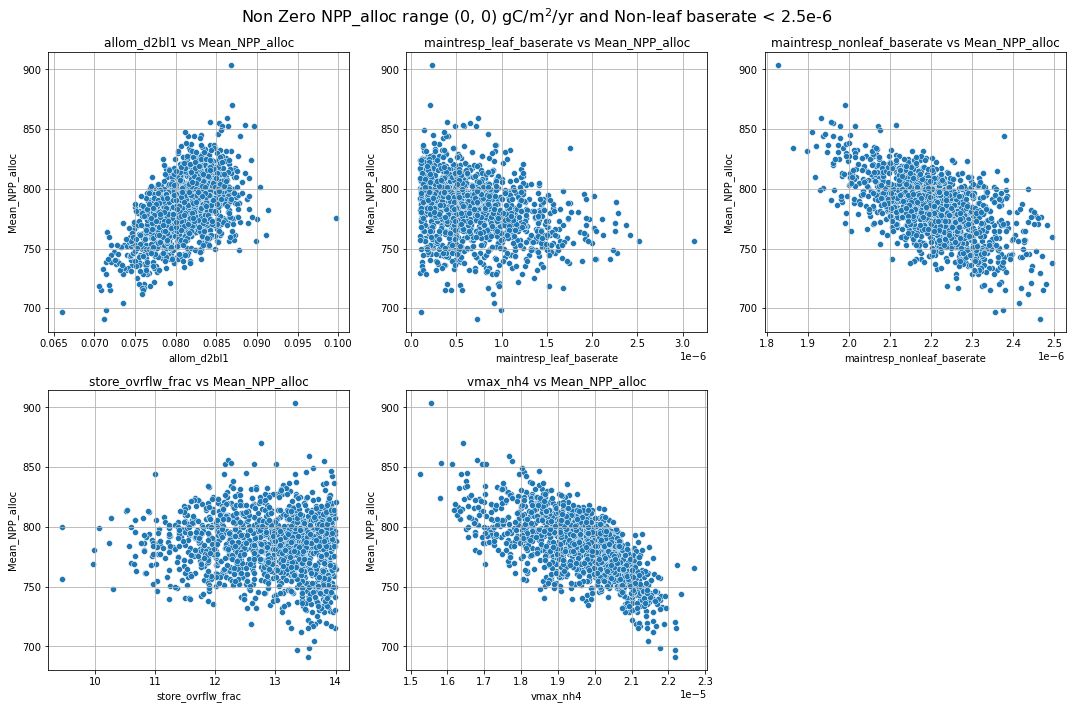

FACE_r250211_ECAornl_enCalB_ECA_US-ORN_I20TRELMFATES_aCO2combined_output


In [199]:

# Create a function to generate scatter plots
if "response" not in fname:
    # Set up the figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    #postive only dataframe 
    df_tmp = PositiveOnly_df.copy()
    
    # Get column names
    param_cols = df_tmp.columns[:5]  # First 5 columns
    target_col = df_tmp.columns[-1]   # 6th column
    
    # Create scatter plots
    for idx, param in enumerate(param_cols):
        sns.scatterplot(data=df_tmp, x=param, y=target_col, ax=axes[idx])
        axes[idx].set_title(f'{param} vs {target_col}')
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel(target_col)
        axes[idx].grid()
    
    # Remove the extra subplot
    axes[5].remove()
    
    #plt.suptitle(f"Non Zero NPP_alloc range {min_value, max_value} gC/m$^2$/yr and Non-leaf baserate < 4e-6", fontsize=16)
    plt.suptitle(f"Non Zero NPP_alloc range {min_value, max_value} gC/m$^2$/yr and Non-leaf baserate < 2.5e-6", fontsize=16)
    
    # Adjust layout
    plt.tight_layout()
    
    plt.show()
    fig.savefig(f"{path}/{fname}_scatter_PositiveOnly_test.png",bbox_inches="tight")
    print (fname)

In [200]:

# Create a function to generate scatter plots
if "response" in fname:
    # Set up the figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    #postive only dataframe 
    df_tmp = PositiveOnly_df.copy()
    
    # Get column names
    param_cols = df_tmp.columns[:5]  # First 5 columns
    target_col = df_tmp.columns[-1]   # 6th column
    
    # Create scatter plots
    for idx, param in enumerate(param_cols):
        sns.scatterplot(data=df_tmp, x=param, y=target_col, ax=axes[idx])
        axes[idx].set_title(f'{param} vs {target_col}')
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel(target_col)
        axes[idx].grid()
    
    # Remove the extra subplot
    axes[5].remove()
    
    #plt.suptitle(f"Non Zero NPP_alloc range {min_value, max_value} gC/m$^2$/yr and Non-leaf baserate < 4e-6", fontsize=16)
    plt.suptitle(f"Non Zero NPP_alloc_response range {min_value, max_value} gC/m$^2$/yr and Non-leaf baserate < 2.5e-6", fontsize=16)
    
    # Adjust layout
    plt.tight_layout()
    
    plt.show()
    fig.savefig(f"{path}/{fname}_scatter_Response_PositiveOnly_test.png",bbox_inches="tight")
    print (fname)

In [201]:
# Define the range
min_value, max_value = 500, 1300

# Filter rows where all values in columns 6 through last are within the range
valid_df = df[(df.iloc[:, 5:] >= min_value).all(axis=1) & (df.iloc[:, 5:] <= max_value).all(axis=1)]
valid_df.reset_index(drop=True,inplace=True)
# Calculating Mean NPP
valid_df["Mean_NPP_alloc"] = valid_df.iloc[:, 5:].mean(axis=1)
# Save valid_df to a CSV file without including the index
valid_df.to_csv(f"{path}/{fname}_valid.csv", index=False)

In [202]:
valid_df

,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11,Mean_NPP_alloc
0,0.082740,1.530074e-06,0.000002,11.720767,0.000019,778.017791,815.369685,813.206098,842.672730,741.816545,847.707777,809.785608,762.648881,733.637866,682.728488,750.736579,779.848004
1,0.082930,1.498836e-06,0.000002,12.860477,0.000020,790.959645,828.760169,825.618094,854.398695,753.437502,858.718058,820.219406,772.436357,744.539277,693.868429,769.099210,792.004986
2,0.086442,1.361255e-06,0.000002,12.679450,0.000019,839.531363,839.123424,806.265705,901.817958,722.096376,846.880149,807.086831,755.714685,722.663945,668.194236,747.517121,786.990163
3,0.083275,8.595320e-07,0.000002,12.453232,0.000018,800.319268,837.178571,836.142300,861.465229,763.933789,871.529864,834.376870,786.208805,757.253200,702.142022,771.315137,801.987732
4,0.076054,7.908294e-07,0.000002,13.352479,0.000021,746.595822,780.206839,780.379287,804.769306,691.420503,794.144679,771.890811,724.399587,699.139352,640.344569,673.259207,736.959087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.077801,1.079070e-07,0.000002,13.753169,0.000020,809.717692,843.818652,841.933361,871.727153,745.213692,857.209864,835.070219,788.208501,763.420720,695.495139,708.622700,796.403427
1496,0.081944,7.503023e-07,0.000002,12.886802,0.000019,807.911843,843.627367,841.308376,868.801656,768.591680,872.705052,835.559484,788.249174,760.506178,701.741797,775.241903,805.840410
1497,0.073445,4.890769e-07,0.000002,12.617491,0.000021,748.120581,779.510380,778.498758,805.279487,692.407361,787.658679,771.017276,724.020821,702.272760,646.281213,662.500796,736.142556
1498,0.075285,3.703783e-07,0.000002,13.712102,0.000021,763.169499,795.231626,794.703835,821.740274,706.327909,808.530109,787.301560,740.064223,716.250437,656.257044,667.188453,750.614997


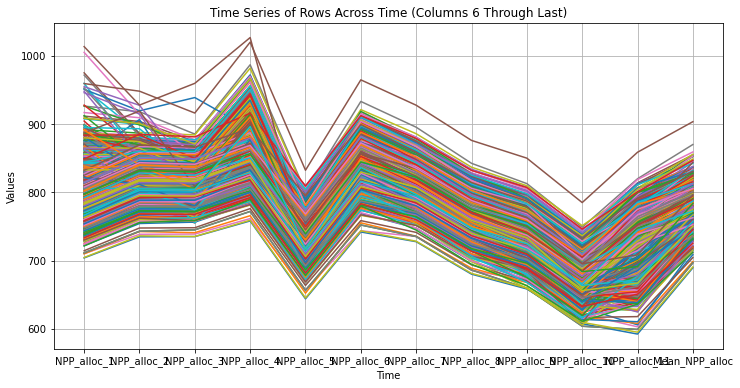

In [203]:

# Assuming valid_df is the DataFrame
time = valid_df.columns[5:]  # Columns 6th through last are time points
rows = valid_df.index  # Rows correspond to individual series

# Plot the time series for each row
plt.figure(figsize=(12, 6))
for row in rows:
    plt.plot(time, valid_df.iloc[row, 5:], label=f"Row {row}")

# Add labels, title, and legend
plt.xlabel("Time")
plt.ylabel("Values")
plt.title("Time Series of Rows Across Time (Columns 6 Through Last)")
#plt.legend(title="Rows", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize="small")
plt.grid(True)



In [204]:

# Calculating Mean NPP
valid_df["Mean_NPP_alloc"] = valid_df.iloc[:, 5:].mean(axis=1)

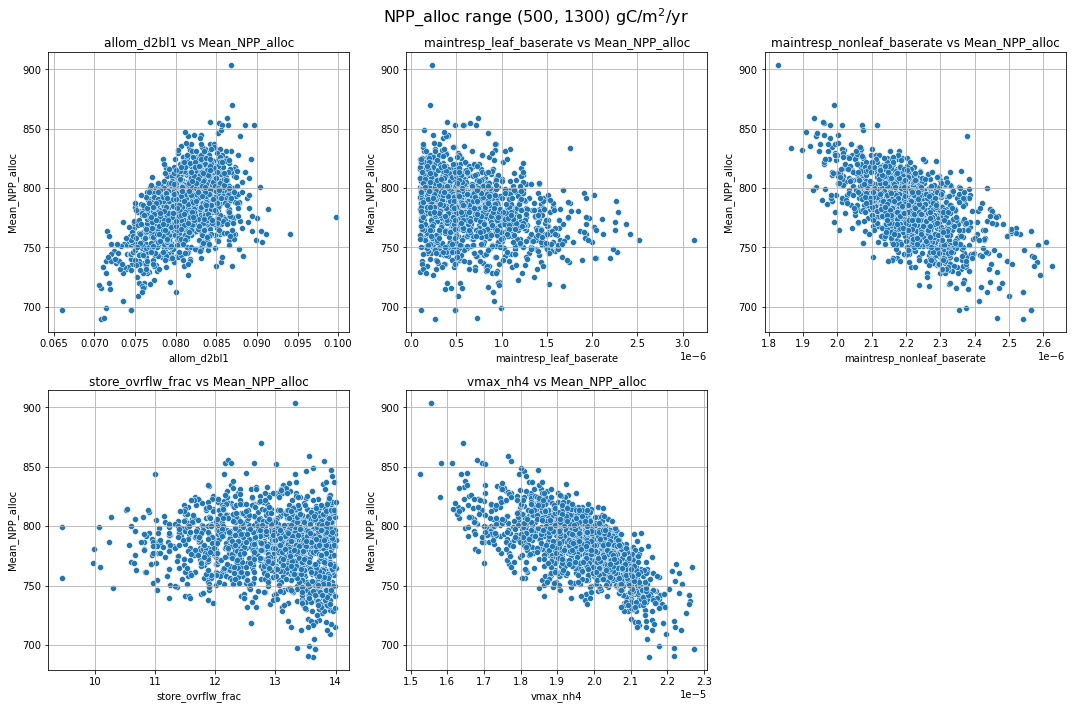

In [205]:

# Create a function to generate scatter plots
if True:
    # Set up the figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    df_tmp = valid_df.copy()
    # Get column names
    param_cols = df_tmp.columns[:5]  # First 5 columns
    target_col = df_tmp.columns[-1]   # 6th column
    
    # Create scatter plots
    for idx, param in enumerate(param_cols):
        sns.scatterplot(data=df_tmp, x=param, y=target_col, ax=axes[idx])
        axes[idx].set_title(f'{param} vs {target_col}')
        axes[idx].set_xlabel(param)
        axes[idx].set_ylabel(target_col)
        axes[idx].grid()
    
    # Remove the extra subplot
    axes[5].remove()
    
    plt.suptitle(f"NPP_alloc range {min_value, max_value} gC/m$^2$/yr", fontsize=16)
    
    # Adjust layout
    plt.tight_layout()
    
    plt.show()
    fig.savefig(f"{path}/{fname}_scatter_valid.png",bbox_inches="tight")

In [206]:
summary_stats = valid_df.describe()
summary_stats.to_csv(f"{path}/{fname}_valid_summary.csv")

In [207]:
summary_stats

,allom_d2bl1,maintresp_leaf_baserate,maintresp_nonleaf_baserate,store_ovrflw_frac,vmax_nh4,NPP_alloc_1,NPP_alloc_2,NPP_alloc_3,NPP_alloc_4,NPP_alloc_5,NPP_alloc_6,NPP_alloc_7,NPP_alloc_8,NPP_alloc_9,NPP_alloc_10,NPP_alloc_11,Mean_NPP_alloc
count,1500.000000,1.500000e+03,1.500000e+03,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.081106,6.536276e-07,2.209230e-06,12.924154,0.000020,795.728861,824.747465,820.228160,863.680704,736.704062,846.143064,814.186631,765.629415,737.434965,678.055787,735.606745,783.467805
std,0.003502,4.508805e-07,1.086849e-07,0.836524,0.000001,36.093416,26.051735,23.660160,37.632909,26.089696,27.676536,24.279987,24.290460,24.664947,24.200041,36.529541,25.531838
min,0.065994,1.003850e-07,1.828410e-06,9.454216,0.000015,704.136687,735.026396,735.303887,758.279205,644.198283,742.122014,727.911973,680.341608,658.671208,604.104968,592.603973,689.665105
25%,0.078821,2.918192e-07,2.142307e-06,12.365414,0.000019,773.162033,807.273384,804.776508,838.233217,719.182699,828.692298,797.470999,749.494799,721.917073,662.128598,717.681664,766.540524
50%,0.081321,5.454955e-07,2.208543e-06,13.124965,0.000020,791.790273,825.725457,821.699666,858.393010,738.026378,848.492231,815.488823,766.883236,738.673023,678.972130,742.972842,785.167800
75%,0.083470,9.090142e-07,2.271739e-06,13.614223,0.000020,809.818025,841.038607,836.111420,881.950769,755.055559,864.752736,830.566099,781.750301,754.221160,693.615119,759.262698,800.293570
max,0.099669,3.122730e-06,2.624875e-06,13.999674,0.000023,1013.564820,948.304068,959.804310,1026.838154,832.524532,964.898885,927.742627,876.221579,850.224961,785.180415,858.872682,903.621584
